Part 5: BatchNorm과 Gradient 안정성
- Minibatch 크기의 영향
- Batch Normalization의 효과
- Gradient 안정성 비교

독립적으로 실행 가능합니다.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 재현성을 위한 시드 고정
torch.manual_seed(42)
np.random.seed(42)

print("=" * 70)
print("Part 5: BatchNorm과 Gradient 안정성")
print("=" * 70)

Part 5: BatchNorm과 Gradient 안정성


In [4]:
# Batch size 가 학습에 미치는 영향

class SimpleNet(nn.Module):
    # BatchNorm 없는 기본 신경망
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(20, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()  # 이진 분류(1/0)
        )

    def forward(self, x):
        return self.network(x)

In [5]:
# 데이터셋 준비

X, y =\
make_classification(
    n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=42
)

In [6]:
# 데이터 분할
X_train, X_test, y_train, y_test =\
train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [10]:
# X_train[:2]
X_test[:2]

array([[ -3.32850077,  -2.20018002,  -0.20749963,  -1.45740886,
         -2.00767193,  -1.25821794,  -1.05411   ,   0.94484676,
          2.96747447,  -0.14390068,  -1.35274829,   5.14232672,
         -2.05572016,   0.69347055,   1.28456823,   0.35083878,
         -1.13756615,   1.04340086,   1.71733973,   0.40017656],
       [-12.91713343,   1.68276426,   2.62480941,  -1.99204428,
         -3.49840499,   2.42561544,  -0.15679461,  -1.04321382,
          4.23602846,   1.39591086,   3.94483847,   2.12406715,
         -0.65757175,  -6.26439163,  -1.80475942,  -7.0266726 ,
          2.74265732,  -0.16545511,   2.36397325,   1.77271933]])

In [12]:
# 표준화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # 훈련용 데이터에만 fit 사용
# X_train[:2]
X_test = scaler.transform(X_test)
# X_test[:2]

In [17]:
# tensor로 변환
X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)

print(X_train_t.shape)
print(X_train.shape)
print(y_train.shape)

torch.Size([800, 20])
(800, 20)
(800,)


In [20]:
# torch.FloatTensor(y_train).unsqueeze(1).shape
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)

In [21]:
# 다양한 Batch_size 학습
batch_sizes = [8, 32, 128, 512]
criterion = nn.BCELoss()

In [22]:
batch_size_results = []

for batch_size in batch_sizes:

    # 데이터 로더 생성
    dataset = TensorDataset(X_train_t, y_train_t)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # 모델 초기화
    model = SimpleNet()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # 학습
    losses = []
    # num_epochs = 30
    num_epochs = 5

    for epoch in range(num_epochs):
        epoch_loss = 0
        for batch_X, batch_y in dataloader:
            model.train()
            optimizer.zero_grad()

            output = model(batch_X)
            loss = criterion(output, batch_y)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(dataloader)
        losses.append(avg_loss)

    batch_size_results.append((batch_size, losses))
    print(f'최종손실: {losses[-1]:.4f}')


최종손실: 0.1351
최종손실: 0.2690
최종손실: 0.5596
최종손실: 0.6641


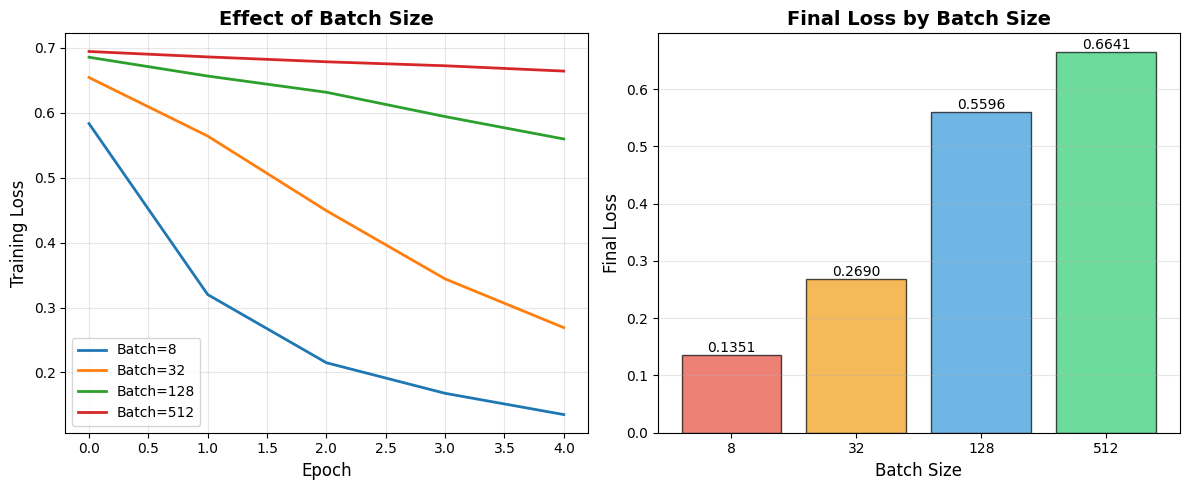


저장: part5_batch_size_effect.png


In [25]:
# 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for batch_size, losses in batch_size_results:
    plt.plot(losses, label=f'Batch={batch_size}', linewidth=2)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.title('Effect of Batch Size', fontsize=14, weight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
final_losses = [losses[-1] for _, losses in batch_size_results]
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
bars = plt.bar([str(bs) for bs in batch_sizes], final_losses,
               color=colors, edgecolor='black', alpha=0.7)

plt.xlabel('Batch Size', fontsize=12)
plt.ylabel('Final Loss', fontsize=12)
plt.title('Final Loss by Batch Size', fontsize=14, weight='bold')
plt.grid(axis='y', alpha=0.3)

# 값 표시
for bar, loss in zip(bars, final_losses):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{loss:.4f}', ha='center', va='bottom', fontsize=10)


plt.tight_layout()
plt.show()
plt.savefig('part5_batch_size_effect.png', dpi=150, bbox_inches='tight')
print("\n저장: part5_batch_size_effect.png")
plt.close()

In [26]:
# BatchNorm 없는 네트워크 VS BatchNorm 있는 네트워크

class NetWithoutBN(nn.Module):
    """BatchNorm 없는 깊은 신경망"""
    def __init__(self):
        super(NetWithoutBN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(20, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


class NetWithBN(nn.Module):
    """BatchNorm 있는 깊은 신경망"""
    def __init__(self):
        super(NetWithBN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(20, 64),
            nn.BatchNorm1d(64),  # BatchNorm 추가
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

In [28]:
# 두 모델 학습
models_to_compare = [
    ('Without BN', NetWithoutBN()),
    ('With BN', NetWithBN())
]

comparison_results = []

# 데이터로더 생성 (Batch size=32)
dataset = TensorDataset(X_train_t, y_train_t)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

for model_name, model in models_to_compare:
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    losses = []
    # num_epochs = 50
    num_epochs = 5

    for epoch in range(num_epochs):
        epoch_loss = 0
        for batch_X, batch_y in dataloader:
            model.train()
            optimizer.zero_grad()

            output = model(batch_X)
            loss = criterion(output, batch_y)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)
        losses.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f' epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.3f}')

    comparison_results.append((model_name, losses))


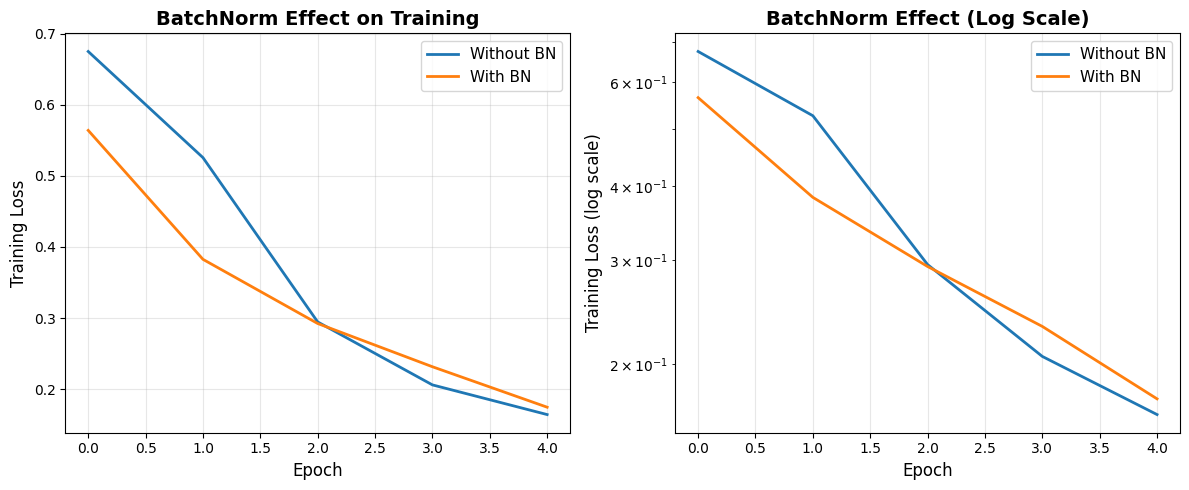


저장: part5_batchnorm_effect.png


In [29]:
# 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for model_name, losses in comparison_results:
    plt.plot(losses, label=model_name, linewidth=2)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.title('BatchNorm Effect on Training', fontsize=14, weight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
for model_name, losses in comparison_results:
    plt.plot(losses, label=model_name, linewidth=2)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Training Loss (log scale)', fontsize=12)
plt.title('BatchNorm Effect (Log Scale)', fontsize=14, weight='bold')
plt.yscale('log')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig('part5_batchnorm_effect.png', dpi=150, bbox_inches='tight')
print("\n저장: part5_batchnorm_effect.png")
plt.close()

In [33]:
# BatchNorm 의 gradient 안정화 효과

# gradient 수집
grad_hist_without_bn = []
grad_hist_with_bn = []

# 새 모델 생성
model_without_bn = NetWithoutBN()
model_with_bn = NetWithBN()

# gradient 기록 (hook)

def create_gradient_hook(gradient_list):
    # gradient 를 리스트에 저장하는 hook 생성
    def hook(grad):
        gradient_list.append(grad.abs().mean().item())
        return grad
    return hook

# without bn
for name, param in model_without_bn.named_parameters():
    if 'weight' in name:
        param.register_hook(create_gradient_hook(grad_hist_without_bn))

# with bn
for name, param in model_with_bn.named_parameters():
    if 'weight' in name:
        param.register_hook(create_gradient_hook(grad_hist_with_bn))

batch_X = X_train_t[:32] # 배치크기 32
batch_y = y_train_t[:32]

# without bn
output_without = model_without_bn(batch_X)
loss_without = criterion(output_without, batch_y)
loss_without.backward()

# with bn
output_with = model_with_bn(batch_X)
loss_with = criterion(output_with, batch_y)
loss_with.backward()

# gradient 역순 정렬 (layer1부터 표시)
grad_hist_without_bn.reverse()
grad_hist_with_bn.reverse()

# 각 층의 gradient 크기

print("Without BN")
for i, grad in enumerate(grad_hist_without_bn):
    print(f' Layer {i+1}: {grad:.4f}')

print("With BN")
for i, grad in enumerate(grad_hist_with_bn):
    print(f' Layer {i+1}: {grad:.4f}')

Without BN
 Layer 1: 0.0003
 Layer 2: 0.0003
 Layer 3: 0.0003
 Layer 4: 0.0007
 Layer 5: 0.0081
With BN
 Layer 1: 0.0144
 Layer 2: 0.0064
 Layer 3: 0.0102
 Layer 4: 0.0044
 Layer 5: 0.0083
 Layer 6: 0.0035
 Layer 7: 0.0087
 Layer 8: 0.0101
 Layer 9: 0.0961


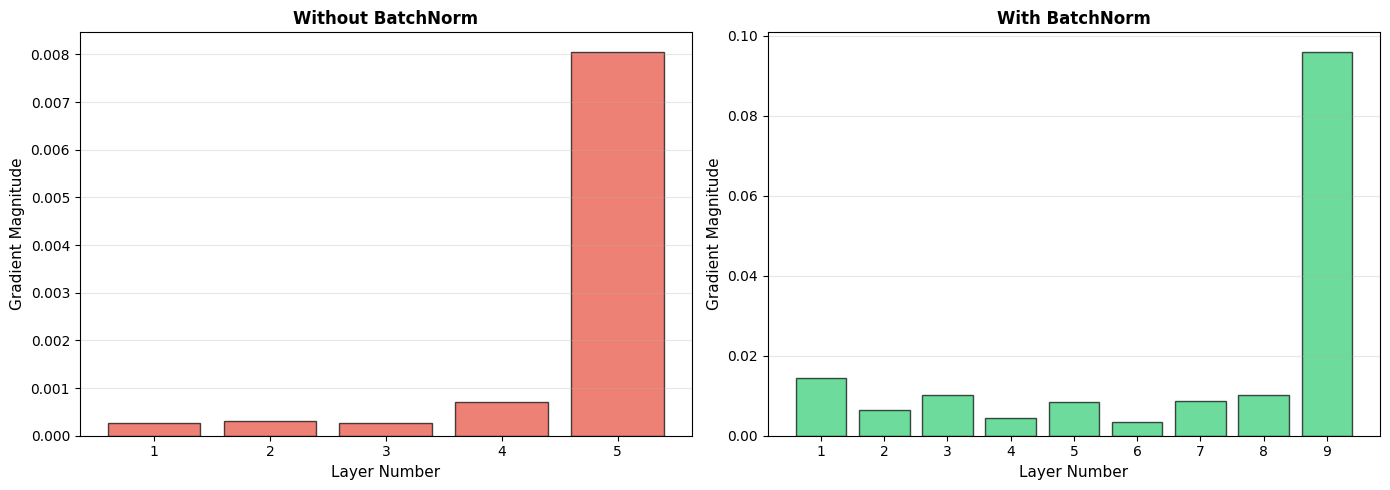


저장: part5_gradient_stability.png

분석:
  - BatchNorm 없음: 층마다 그래디언트 크기 차이가 큼
  - BatchNorm 있음: 적어도 8개 층까지는 유사하게 그래디언트가 비슷한 크기
  - 결과: 더 안정적인 학습 가능


In [36]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Without BN
ax1 = axes[0]
layers = list(range(1, len(grad_hist_without_bn) + 1))
ax1.bar(layers, grad_hist_without_bn, color='#e74c3c',
        edgecolor='black', alpha=0.7)
ax1.set_xlabel('Layer Number', fontsize=11)
ax1.set_ylabel('Gradient Magnitude', fontsize=11)
ax1.set_title('Without BatchNorm', fontsize=12, weight='bold')
ax1.set_xticks(layers)
ax1.grid(axis='y', alpha=0.3)

# With BN
ax2 = axes[1]
layers = list(range(1, len(grad_hist_with_bn) + 1))
ax2.bar(layers, grad_hist_with_bn, color='#2ecc71',
        edgecolor='black', alpha=0.7)
ax2.set_xlabel('Layer Number', fontsize=11)
ax2.set_ylabel('Gradient Magnitude', fontsize=11)
ax2.set_title('With BatchNorm', fontsize=12, weight='bold')
ax2.set_xticks(layers)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig('part5_gradient_stability.png', dpi=150, bbox_inches='tight')
print("\n저장: part5_gradient_stability.png")
plt.close()

print("\n분석:")
print("  - BatchNorm 없음: 층마다 그래디언트 크기 차이가 큼")
print("  - BatchNorm 있음: 적어도 8개 층까지는 유사하게 그래디언트가 비슷한 크기")
print("  - 결과: 더 안정적인 학습 가능")

In [37]:
# batch size에서 BatchNorm 효과

batch_sizes_test = [8, 16, 32, 64]

results_comparison = {}

for batch_size in batch_sizes_test:
    dataset = TensorDataset(X_train_t, y_train_t)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # without bn
    model_no_bn = NetWithoutBN()
    optimizer_no_bn = optim.Adam(model_no_bn.parameters(), lr=0.001)

    losses_no_bn = []

    for epoch in range(5):
        epoch_loss = 0
        for batch_X, batch_y in dataloader:
            model_no_bn.train()
            optimizer_no_bn.zero_grad()

            output = model_no_bn(batch_X)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer_no_bn.step()

            epoch_loss += loss.item()
        losses_no_bn.append(epoch_loss / len(dataloader))

    # with bn
    model_with_bn = NetWithBN()
    optimizer_with_bn = optim.Adam(model_with_bn.parameters(), lr=0.001)

    losses_with_bn = []

    for epoch in range(5):
        epoch_loss = 0
        for batch_X, batch_y in dataloader:
            model_with_bn.train()
            optimizer_with_bn.zero_grad()

            output = model_with_bn(batch_X)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer_with_bn.step()

            epoch_loss += loss.item()
        losses_with_bn.append(epoch_loss / len(dataloader))

    results_comparison[batch_size] = {
        'without_bn': losses_no_bn,
        'with_bn': losses_with_bn
    }

    print(f' without bn 최종 손실: {losses_no_bn[-1]:.4f}')
    print(f' with bn 최종 손실: {losses_with_bn[-1]:.4f}')


 without bn 최종 손실: 0.0990
 with bn 최종 손실: 0.3222
 without bn 최종 손실: 0.1092
 with bn 최종 손실: 0.2002
 without bn 최종 손실: 0.1499
 with bn 최종 손실: 0.1909
 without bn 최종 손실: 0.2669
 with bn 최종 손실: 0.2309


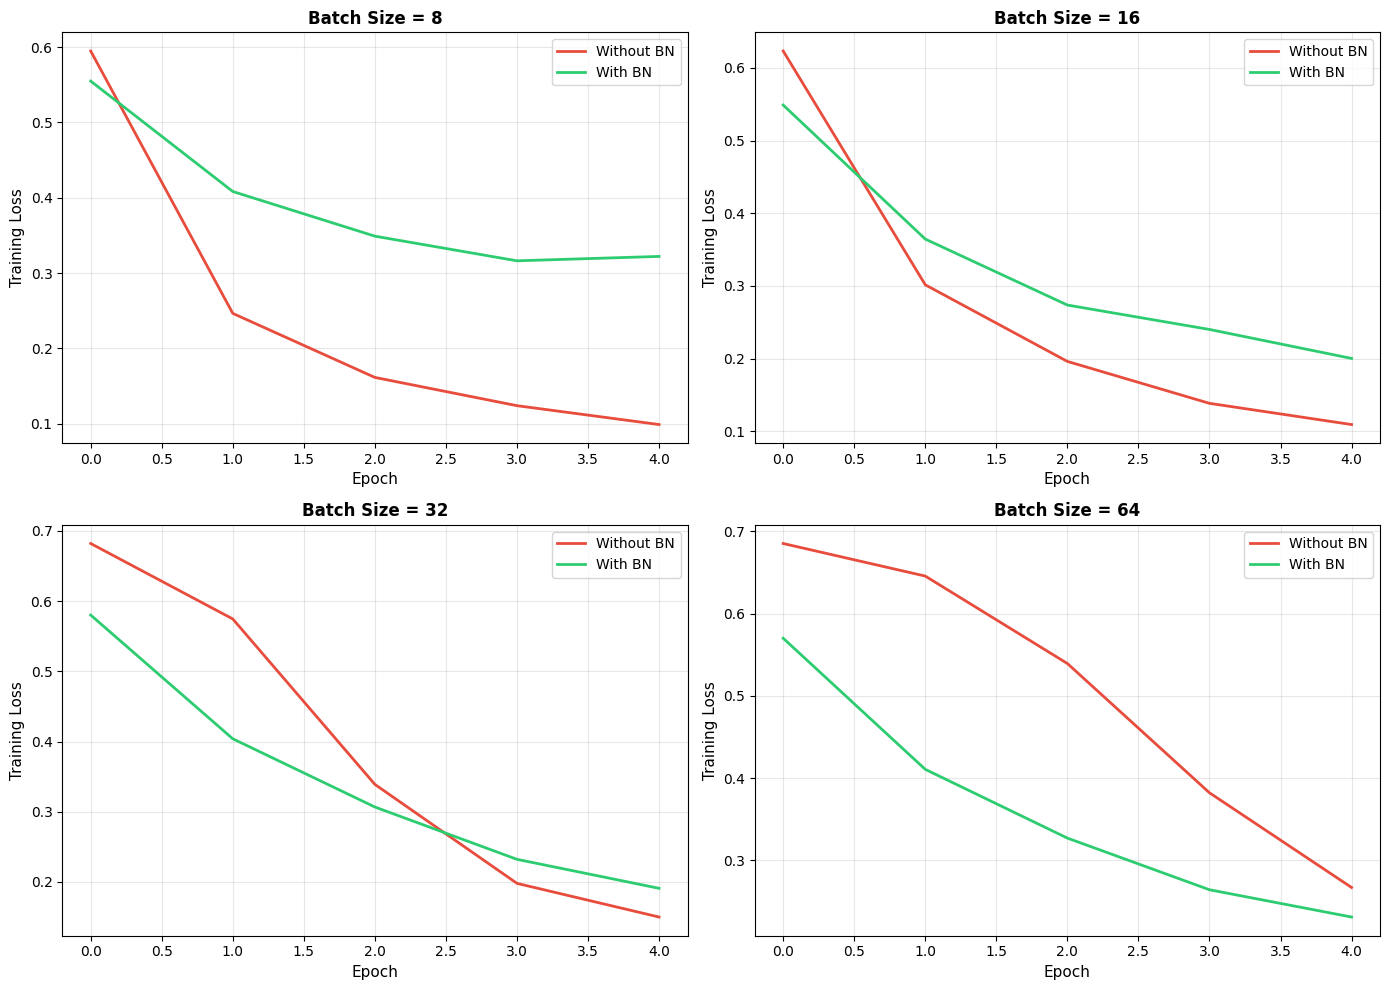


저장: part5_batchnorm_various_batch_sizes.png


In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, batch_size in enumerate(batch_sizes_test):
    ax = axes[idx // 2, idx % 2]

    losses_no_bn = results_comparison[batch_size]['without_bn']
    losses_with_bn = results_comparison[batch_size]['with_bn']

    ax.plot(losses_no_bn, label='Without BN', linewidth=2, color='#e74c3c')
    ax.plot(losses_with_bn, label='With BN', linewidth=2, color='#2ecc71')

    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Training Loss', fontsize=11)
    ax.set_title(f'Batch Size = {batch_size}', fontsize=12, weight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig('part5_batchnorm_various_batch_sizes.png', dpi=150, bbox_inches='tight')
print("\n저장: part5_batchnorm_various_batch_sizes.png")
plt.close()

In [ ]:
# 결론 : Batch size가 클수록 정확(batch normalization 중요, 평균과 분산 사용하기 때문)

In [39]:
# BatchNorm 학습 모드 vs 평가 모드

In [40]:
# BatchNorm이 있는 모델 생성 및 학습
model_bn = NetWithBN()
optimizer = optim.Adam(model_bn.parameters(), lr=0.001)

dataset = TensorDataset(X_train_t, y_train_t)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

print("\n모델 학습 중...")
for epoch in range(30):
    for batch_X, batch_y in dataloader:
        model_bn.train()  # 학습 모드
        optimizer.zero_grad()
        output = model_bn(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()

print("학습 완료")

# 테스트 데이터
X_test_t = torch.FloatTensor(X_test)

print("\n학습 모드 vs 평가 모드 출력 비교:")

# 학습 모드에서 여러 번 예측
model_bn.train()
predictions_train_mode = []
for _ in range(5):
    with torch.no_grad():
        pred = model_bn(X_test_t[:10])
        predictions_train_mode.append(pred.numpy())

# 평가 모드에서 여러 번 예측
model_bn.eval()
predictions_eval_mode = []
for _ in range(5):
    with torch.no_grad():
        pred = model_bn(X_test_t[:10])
        predictions_eval_mode.append(pred.numpy())

# 예측 분산 계산
variance_train = np.var(predictions_train_mode, axis=0).mean()
variance_eval = np.var(predictions_eval_mode, axis=0).mean()

print(f"\n학습 모드 예측 분산: {variance_train:.8f}")
print(f"평가 모드 예측 분산: {variance_eval:.8f}")

print("\n설명:")
print("  - 학습 모드: 각 배치의 통계 사용 -> 예측이 약간 다름")
print("  - 평가 모드: 전체 데이터의 Moving Average 사용 -> 일관된 예측")
print("  - 중요: model.eval()을 반드시 사용해야 함!")


모델 학습 중...
학습 완료

학습 모드 vs 평가 모드 출력 비교:

학습 모드 예측 분산: 0.00000000
평가 모드 예측 분산: 0.00000000

설명:
  - 학습 모드: 각 배치의 통계 사용 -> 예측이 약간 다름
  - 평가 모드: 전체 데이터의 Moving Average 사용 -> 일관된 예측
  - 중요: model.eval()을 반드시 사용해야 함!


최종 요약

In [41]:
print("\n핵심 개념:")
print("\n1. Batch Size의 영향")
print("   - 작은 배치: 노이즈 많음, 정규화 효과")
print("   - 큰 배치: 안정적, GPU 활용 좋음")
print("   - 권장: 32-128 사이")

print("\n2. Batch Normalization")
print("   - 목적: 각 층의 입력 분포 안정화")
print("   - 효과: 빠른 학습, 높은 학습률 가능")
print("   - 위치: Linear/Conv -> BN -> Activation")

print("\n3. Gradient 안정화")
print("   - BN 없음: 층마다 그래디언트 크기 차이")
print("   - BN 있음: 모든 층에서 균일한 그래디언트")
print("   - 결과: 깊은 네트워크 학습 가능")

print("\n4. 학습/평가 모드")
print("   - 학습: 현재 배치 통계 사용")
print("   - 평가: Moving Average 사용")
print("   - 필수: model.train() / model.eval() 구분")

print("\n생성된 파일:")
print("  1. part5_batch_size_effect.png - Batch Size 영향")
print("  2. part5_batchnorm_effect.png - BatchNorm 효과")
print("  3. part5_gradient_stability.png - Gradient 안정성")
print("  4. part5_batchnorm_various_batch_sizes.png - 다양한 배치에서 BN 효과")


핵심 개념:

1. Batch Size의 영향
   - 작은 배치: 노이즈 많음, 정규화 효과
   - 큰 배치: 안정적, GPU 활용 좋음
   - 권장: 32-128 사이

2. Batch Normalization
   - 목적: 각 층의 입력 분포 안정화
   - 효과: 빠른 학습, 높은 학습률 가능
   - 위치: Linear/Conv -> BN -> Activation

3. Gradient 안정화
   - BN 없음: 층마다 그래디언트 크기 차이
   - BN 있음: 모든 층에서 균일한 그래디언트
   - 결과: 깊은 네트워크 학습 가능

4. 학습/평가 모드
   - 학습: 현재 배치 통계 사용
   - 평가: Moving Average 사용
   - 필수: model.train() / model.eval() 구분

생성된 파일:
  1. part5_batch_size_effect.png - Batch Size 영향
  2. part5_batchnorm_effect.png - BatchNorm 효과
  3. part5_gradient_stability.png - Gradient 안정성
  4. part5_batchnorm_various_batch_sizes.png - 다양한 배치에서 BN 효과
